In [36]:
import pandas as pd

# 모든 컬럼이 보이도록 설정
pd.set_option('display.max_columns', None)


# 컬럼 너비 제한 해제 (내용이 길 때 잘리지 않게 함)
pd.set_option('display.max_colwidth', None)

In [37]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('mysql+pymysql://root:@localhost/review_analysis?charset=utf8mb4')

# products_all 불러오기
df_pd = pd.read_sql("SELECT * FROM products_all", engine)

# reviews_all 불러오기 (작성일 기준 필터)
query_reviews = """
SELECT * FROM reviews_all
WHERE STR_TO_DATE(작성일, '%%Y-%%m-%%d') <= '2026-03-31'
"""
df_rv = pd.read_sql(query_reviews, engine)

print("products:", df_pd.shape)
print("reviews:", df_rv.shape)
print(df_pd.head())
print(df_rv.head())

products: (1541, 12)
reviews: (548248, 14)
   goodsNo  플랫폼 카테고리     브랜드                         상품명     정가    판매가  할인율  \
0   876246  무신사   상의  필루미네이트       [블랙]B-스테디 하프 폴라넥-아이보리  26000  19900   23   
1   876277  무신사   상의  필루미네이트         [블랙]B-스테디 하프 폴라넥-블랙  26000  19900   23   
2   876284  무신사   상의  필루미네이트        [블랙]SET B-스테디 하프 폴라넥  52000  29900   43   
3   994588  무신사   상의  필루미네이트  옵티멀 베이직 셔츠-화이트[린넨＆옥스포드 선택]  53000  22900   57   
4   994600  무신사   상의  필루미네이트  옵티멀 베이직 셔츠-네이비[린넨&옥스포드 선택]  53000  22900   57   

     조회수  누적판매수    리뷰수  리뷰점수  
0    624  16692   3685    94  
1    906  47033   9555    96  
2    886  67962  14298    94  
3  20788  97167  14464    96  
4   8560  14528   2489    96  
      리뷰번호  goodsNo    작성자  \
0  2848952   876284   tejj   
1  2850077   876284      -   
2  2850085   876284      -   
3  2850098   876284      -   
4  2850905   876284  호야호야요   

                                                                           리뷰내용  \
0  너무 오버하지도 않아서 이너티로 딱 맞을 것 같아요!

goodsNo,리뷰번호,작성자,리뷰내용,평점,체험단,작성일,만족도,사진유무,도움돼요

In [38]:
df_rv.dtypes

리뷰번호       int64
goodsNo    int64
작성자          str
리뷰내용         str
평점         int64
체험단          str
구매옵션         str
키          int64
몸무게        int64
성별           str
작성일          str
만족도          str
사진유무         str
도움돼요       int64
dtype: object

### 작성일 데이터 형식 변환

In [39]:
# 문자열(str) -> 날짜(Datetime) 형식으로 변환
df_rv['작성일'] = pd.to_datetime(df_rv['작성일'])

In [40]:
df_rv.dtypes

리뷰번호                           int64
goodsNo                        int64
작성자                              str
리뷰내용                             str
평점                             int64
체험단                              str
구매옵션                             str
키                              int64
몸무게                            int64
성별                               str
작성일        datetime64[us, UTC+09:00]
만족도                              str
사진유무                             str
도움돼요                           int64
dtype: object

### 전체 널값 확인

In [41]:
df_rv.isnull().sum()

리뷰번호            0
goodsNo         0
작성자             0
리뷰내용          235
평점              0
체험단             0
구매옵션          573
키               0
몸무게             0
성별          88749
작성일             0
만족도        531976
사진유무            0
도움돼요            0
dtype: int64

### 만족도

In [42]:
df_rv['만족도']

0                                                            NaN
1                                                            NaN
2                                                            NaN
3                                                            NaN
4                                                            NaN
                                   ...                          
548243         사이즈: 정사이즈 / 화면 대비 색감: 화면과 비슷 / 퀄리티: 보통 / 신축성: 적당함
548244      사이즈: 정사이즈 / 화면 대비 색감: 화면과 비슷 / 퀄리티: 매우 좋음 / 신축성: 적당함
548245         사이즈: 정사이즈 / 화면 대비 색감: 화면과 비슷 / 퀄리티: 보통 / 신축성: 적당함
548246         사이즈: 정사이즈 / 화면 대비 색감: 화면과 비슷 / 퀄리티: 보통 / 신축성: 적당함
548247    사이즈: 정사이즈 / 화면 대비 색감: 화면과 비슷 / 퀄리티: 매우 좋음 / 신축성: 매우 강함
Name: 만족도, Length: 548248, dtype: str

In [43]:
# '만족도'가 결측치(NaN)인 데이터만 추출하여 상위 10개 출력
nan_samples = df_rv[df_rv['만족도'].isna()].head(10)

# 주요 컬럼들과 함께 출력하여 패턴 파악
print("--- 만족도 결측 데이터 샘플 ---")
display(nan_samples[['작성일', '평점', 'goodsNo', '리뷰내용','만족도']])

--- 만족도 결측 데이터 샘플 ---


,작성일,평점,goodsNo,리뷰내용,만족도
0,2018-10-16 11:58:00+09:00,5,876284,너무 오버하지도 않아서 이너티로 딱 맞을 것 같아요!\n포인트 컬러로도 활용할 수 있게 반폴라로 되어있구 원단도 부드러워서 딱이네요 ~~,NaN
1,2018-10-16 14:57:45+09:00,5,876284,가격대비 매우 만족\n소재도 부드럽고 어느자켓이든 소화가능\n기장이 짧은느낌이있는데 다른컬러 L사이즈 구입해야겠어요!\n만족합니다!,NaN
2,2018-10-16 14:58:55+09:00,5,876284,가격대비 매우 만족\n소재도 부드럽고 어느자켓이든 소화가능\n기장이 짧은느낌이있는데 다른컬러 L사이즈 구입해야겠어요!\n만족합니다!,NaN
3,2018-10-16 15:00:56+09:00,5,876284,가격에 비해 퀄리티가 너무좋아요!\n원단도 느낌좋코 차콜 컬러가 너무맘에들어요\n득템!,NaN
4,2018-10-16 16:58:55+09:00,5,876284,폴라 필요하다해서 선물했는데 너무 맘에들어하네영 예쁩니당 ㅎㅎ 엄청깔끔하고 \n가성비대비 엄청 고급스럽네용 다른컬러로 추가구매해야겠어여,NaN
5,2018-10-16 17:04:54+09:00,5,876284,지인 선물해줬는데 \n\n저번에 티셔츠도 세트로 샀었는데 그거 만큼 괜찮고 일단 저렴해서 퀄리티 별생각 안했는데 따뜻하고 원단도 좋아서 놀랐다 \n\n고 합니다 !! 필루미네이트 짱입니다 정말 저도 사야겠습니당,NaN
6,2018-10-16 18:37:11+09:00,5,876284,예쁩니다~~~~~~~~~~~~~~~~~~~~~~예뻐요옸 이거위에 셔츠걸치거나 맨퉅맨입어도 잘어울릴거같고~~~~~\n그냥 여기저기 활용하게 조을듯~~ 베이지 색감되게 연하고 네이비는 네이비~~~~~~~~~~~~~~~~~~~~~~\n소재가 되게 좋네요 부들부들 핏도 딱맞아 떨어지는 느낌이예요~~~~~~~~~~,NaN
7,2018-10-17 18:07:03+09:00,5,876284,사진 이상해서 다시올려여~~~~~~~~~~~~178이니까 참고해주세여~~~~~\n되게 예쁩니다~~~~~~~~~~~~~~~,NaN
8,2018-10-17 22:24:31+09:00,5,876277,겨울에 안에입기 너무 좋을거같아요 가성비와 핏 모두 만족합니다 ㅎ,NaN
9,2018-10-18 02:13:30+09:00,5,876284,집에 그냥 저렴한 반목티 몇장 입고있는데 이건 재질이 엄청 짱짱해서 약간 이너웨어 느낌도 나네요 이너로 입을걸로 산거라서 마음에듭니다,NaN


In [44]:
from collections import Counter

all_keys = []
for tag in df_rv['만족도'].dropna():
    parts = tag.split('/')
    for p in parts:
        if ':' in p:
            all_keys.append(p.split(':')[0].strip())

# 어떤 항목이 몇 번 나왔는지 확인
print(Counter(all_keys))

Counter({'사이즈': 16272, '화면 대비 색감': 15808, '퀄리티': 14529, '두께감': 8506, '신축성': 6495, '보온성': 1543, '구김': 1287, '색감': 459})


In [45]:

# 만족도: 텍스트 파싱 → 개별 컬럼 분리 + 순서형 범주형 변환

def _parse_satisfaction(text):
    if pd.isna(text) or text == "":
        return None
    result = {}
    for part in str(text).split('/'):
        if ':' in part:
            key, value = part.split(':', 1)
            result[key.strip()] = value.strip()
    return result

parsed = df_rv['만족도'].apply(_parse_satisfaction)
sat_df = pd.DataFrame(parsed.dropna().tolist())
sat_df.index = df_rv[df_rv['만족도'].notnull()].index
sat_df = sat_df.reindex(df_rv.index)

# 응답여부 플래그
df_rv['만족도_응답여부'] = np.where(df_rv['만족도'].notnull(), '응답', '미응답')

# 개별 항목 컬럼 추가
for col in sat_df.columns:
    df_rv[col] = sat_df[col]

# 순서형 범주형(Ordered Categorical) 변환
categories_dict = {
    '사이즈':       ['매우 작음', '조금 작음', '정사이즈', '조금 큼', '많이 큼'],
    '화면 대비 색감': ['매우 어두움', '어두움', '화면과 비슷', '밝음', '매우 밝음'],
    '퀄리티':       ['매우 나쁨', '나쁨', '보통', '좋음', '매우 좋음'],
    '구김':         ['매우 많음', '많음', '약간 있음', '거의 없음', '전혀 없음'],
    '두께감':       ['매우 얇음', '얇음', '적당함', '두꺼움', '매우 두꺼움'],
    '신축성':       ['전혀 없음', '거의 없음', '적당함', '강함', '매우 강함'],
    '색감':         ['어두움', '화면과 비슷', '밝음', '매우 밝음'],
    '보온성':       ['전혀 없음', '거의 없음', '적당함', '좋음', '매우 좋음'],
}

for col, order in categories_dict.items():
    if col in df_rv.columns:
        df_rv[col] = pd.Categorical(df_rv[col], categories=order, ordered=True)

print(" 4. 만족도 파싱 + 범주형 변환 완료")
print(f"   응답: {(df_rv['만족도_응답여부'] == '응답').sum()}건 / 미응답: {(df_rv['만족도_응답여부'] == '미응답').sum()}건")


# ==========================================
# 척도 유형 분류 및 수치 변환
#
# 유형 1 - 선형 만족도 (높을수록 좋음)
#   퀄리티, 보온성, 신축성, 두께감, 구김(반전됨)
#   → _점수 컬럼 생성 (1~5점)
#
# 유형 2 - 중심 기준 편차 (중간값이 이상적)
#   사이즈, 화면 대비 색감, 색감
#   → _편차 (방향 있음), _편차절대 (방향 없음, 0에 가까울수록 이상적)
# ==========================================

# 유형 1: 선형 만족도
linear_cols = ['퀄리티', '보온성', '신축성', '두께감', '구김']

for col in linear_cols:
    if col in df_rv.columns:
        df_rv[f'{col}_점수'] = df_rv[col].cat.codes.replace(-1, np.nan) + 1

print("선형 점수 변환 완료 (1~5점)")
for col in linear_cols:
    if f'{col}_점수' in df_rv.columns:
        print(f"   {col}_점수: {df_rv[f'{col}_점수'].value_counts(dropna=True).to_dict()}")

# 유형 2: 중심 기준 편차
center_cols = ['사이즈', '화면 대비 색감', '색감']

for col in center_cols:
    if col in df_rv.columns:
        n      = len(df_rv[col].cat.categories)
        center = (n - 1) / 2
        code   = df_rv[col].cat.codes.replace(-1, np.nan)
        df_rv[f'{col}_편차']     = code - center
        df_rv[f'{col}_편차절대'] = (code - center).abs()

print("중심 기준 편차 변환 완료")
for col in center_cols:
    if f'{col}_편차' in df_rv.columns:
        print(f"   {col}_편차: {df_rv[f'{col}_편차'].value_counts(dropna=True).to_dict()}")

 4. 만족도 파싱 + 범주형 변환 완료
   응답: 16272건 / 미응답: 531976건
선형 점수 변환 완료 (1~5점)
   퀄리티_점수: {3.0: 7951, 4.0: 3168, 5.0: 2858, 2.0: 386, 1.0: 166}
   보온성_점수: {3.0: 673, 4.0: 478, 5.0: 309, 2.0: 60, 1.0: 23}
   신축성_점수: {3.0: 4752, 2.0: 658, 4.0: 572, 1.0: 318, 5.0: 195}
   두께감_점수: {3.0: 5900, 4.0: 1330, 2.0: 953, 5.0: 182, 1.0: 141}
   구김_점수: {3.0: 771, 4.0: 307, 2.0: 115, 5.0: 76, 1.0: 18}
중심 기준 편차 변환 완료
   사이즈_편차: {0.0: 10822, 1.0: 4151, 2.0: 697, -1.0: 429, -2.0: 173}
   화면 대비 색감_편차: {0.0: 13716, 1.0: 912, -1.0: 790, 2.0: 230, -2.0: 160}
   색감_편차: {-0.5: 431, 0.5: 12, 1.5: 10, -1.5: 6}


In [46]:
df_rv.dtypes

리뷰번호                                 int64
goodsNo                              int64
작성자                                    str
리뷰내용                                   str
평점                                   int64
체험단                                    str
구매옵션                                   str
키                                    int64
몸무게                                  int64
성별                                     str
작성일              datetime64[us, UTC+09:00]
만족도                                    str
사진유무                                   str
도움돼요                                 int64
만족도_응답여부                               str
사이즈                               category
화면 대비 색감                          category
퀄리티                               category
구김                                category
두께감                               category
신축성                               category
색감                                category
보온성                               category
퀄리티_점수     

In [47]:
df_rv.columns

Index(['리뷰번호', 'goodsNo', '작성자', '리뷰내용', '평점', '체험단', '구매옵션', '키', '몸무게', '성별',
       '작성일', '만족도', '사진유무', '도움돼요', '만족도_응답여부', '사이즈', '화면 대비 색감', '퀄리티',
       '구김', '두께감', '신축성', '색감', '보온성', '퀄리티_점수', '보온성_점수', '신축성_점수', '두께감_점수',
       '구김_점수', '사이즈_편차', '사이즈_편차절대', '화면 대비 색감_편차', '화면 대비 색감_편차절대', '색감_편차',
       '색감_편차절대'],
      dtype='str')

In [48]:
# '만족도'가 결측치(NaN)인 데이터만 추출하여 상위 10개 출력
nan_samples = df_rv[df_rv['만족도'].isna()].head()

# 주요 컬럼들과 함께 출력하여 패턴 파악
print("--- 만족도 결측 데이터 샘플 ---")
display(nan_samples.head())

--- 만족도 결측 데이터 샘플 ---


,리뷰번호,goodsNo,작성자,리뷰내용,평점,체험단,구매옵션,키,몸무게,성별,작성일,만족도,사진유무,도움돼요,만족도_응답여부,사이즈,화면 대비 색감,퀄리티,구김,두께감,신축성,색감,보온성,퀄리티_점수,보온성_점수,신축성_점수,두께감_점수,구김_점수,사이즈_편차,사이즈_편차절대,화면 대비 색감_편차,화면 대비 색감_편차절대,색감_편차,색감_편차절대
0,2848952,876284,tejj,너무 오버하지도 않아서 이너티로 딱 맞을 것 같아요!\n포인트 컬러로도 활용할 수 있게 반폴라로 되어있구 원단도 부드러워서 딱이네요 ~~,5,FALSE,M · Beige,0,0,NaN,2018-10-16 11:58:00+09:00,NaN,FALSE,0,미응답,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2850077,876284,-,가격대비 매우 만족\n소재도 부드럽고 어느자켓이든 소화가능\n기장이 짧은느낌이있는데 다른컬러 L사이즈 구입해야겠어요!\n만족합니다!,5,FALSE,M · Black,0,0,NaN,2018-10-16 14:57:45+09:00,NaN,TRUE,0,미응답,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2850085,876284,-,가격대비 매우 만족\n소재도 부드럽고 어느자켓이든 소화가능\n기장이 짧은느낌이있는데 다른컬러 L사이즈 구입해야겠어요!\n만족합니다!,5,FALSE,M · Black,0,0,NaN,2018-10-16 14:58:55+09:00,NaN,TRUE,0,미응답,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2850098,876284,-,가격에 비해 퀄리티가 너무좋아요!\n원단도 느낌좋코 차콜 컬러가 너무맘에들어요\n득템!,5,FALSE,M · Black,0,0,NaN,2018-10-16 15:00:56+09:00,NaN,FALSE,0,미응답,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2850905,876284,호야호야요,폴라 필요하다해서 선물했는데 너무 맘에들어하네영 예쁩니당 ㅎㅎ 엄청깔끔하고 \n가성비대비 엄청 고급스럽네용 다른컬러로 추가구매해야겠어여,5,FALSE,XL · Black,0,0,NaN,2018-10-16 16:58:55+09:00,NaN,TRUE,0,미응답,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
# 1. '만족도'가 결측치가 아닌(데이터가 있는) 것만 추출
not_nan_samples = df_rv[df_rv['만족도'].notna()]

print("--- 만족도 결측 데이터 샘플 ---")
display(not_nan_samples.head())

--- 만족도 결측 데이터 샘플 ---


,리뷰번호,goodsNo,작성자,리뷰내용,평점,체험단,구매옵션,키,몸무게,성별,작성일,만족도,사진유무,도움돼요,만족도_응답여부,사이즈,화면 대비 색감,퀄리티,구김,두께감,신축성,색감,보온성,퀄리티_점수,보온성_점수,신축성_점수,두께감_점수,구김_점수,사이즈_편차,사이즈_편차절대,화면 대비 색감_편차,화면 대비 색감_편차절대,색감_편차,색감_편차절대
81791,75280314,3791889,뽀로롱롱이,핑크핑크 셔츠 갖고싶었는데\n드디어 샀네요\n역시 무신사가 질이 좋네여,5,FALSE,M,167,54,여성,2025-11-05 20:59:55+09:00,사이즈: 정사이즈 / 화면 대비 색감: 화면과 비슷 / 퀄리티: 보통 / 구김: 약간 있음,TRUE,0,응답,정사이즈,화면과 비슷,보통,약간 있음,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,3.0,0.0,0.0,0.0,0.0,NaN,NaN
82225,75583447,3791891,앨빈입니다,더울때는 못입는데 선선할때 입으면 좋을거같아요 할인할때 삿습니다,5,FALSE,M,170,70,남성,2025-11-28 20:35:18+09:00,사이즈: 정사이즈 / 화면 대비 색감: 화면과 비슷 / 퀄리티: 보통 / 구김: 약간 있음,TRUE,0,응답,정사이즈,화면과 비슷,보통,약간 있음,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,3.0,0.0,0.0,0.0,0.0,NaN,NaN
83578,76573570,4911299,깊은그린로맨틱,시원하고 한여름에입기는 더울것 같아요 예쁩니다,5,FALSE,L,178,78,남성,2025-11-19 20:43:57+09:00,사이즈: 정사이즈 / 화면 대비 색감: 화면과 비슷 / 퀄리티: 보통 / 구김: 약간 있음,TRUE,1,응답,정사이즈,화면과 비슷,보통,약간 있음,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,3.0,0.0,0.0,0.0,0.0,NaN,NaN
83759,76693825,4969899,수줍은제주크롭탑,질감도 이뻐보이고 가성비 좋은거 같아요 최고요,5,FALSE,INDIGO · XL,183,85,남성,2025-12-05 00:44:05+09:00,사이즈: 정사이즈 / 화면 대비 색감: 화면과 비슷 / 퀄리티: 보통 / 구김: 약간 있음,FALSE,0,응답,정사이즈,화면과 비슷,보통,약간 있음,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,3.0,0.0,0.0,0.0,0.0,NaN,NaN
84733,77677736,4009326,chloe3011,할인 받고 잘 샀어요:) 사이즈 고민 많이했는데 167 키에 엉덩이 충분히 덮는 기장이에요! 전체적으로 너무 편하고 소재도 너무 시원해서 지금 입기 딱 좋아요~~~,5,FALSE,(BLACK)M,167,59,여성,2026-01-24 00:01:45+09:00,사이즈: 많이 큼 / 화면 대비 색감: 화면과 비슷 / 두께감: 적당함 / 신축성: 적당함,TRUE,0,응답,많이 큼,화면과 비슷,NaN,NaN,적당함,적당함,NaN,NaN,NaN,NaN,3.0,3.0,NaN,2.0,2.0,0.0,0.0,NaN,NaN


In [50]:
print("현재 컬럼 리스트:", df_rv.columns.tolist())

현재 컬럼 리스트: ['리뷰번호', 'goodsNo', '작성자', '리뷰내용', '평점', '체험단', '구매옵션', '키', '몸무게', '성별', '작성일', '만족도', '사진유무', '도움돼요', '만족도_응답여부', '사이즈', '화면 대비 색감', '퀄리티', '구김', '두께감', '신축성', '색감', '보온성', '퀄리티_점수', '보온성_점수', '신축성_점수', '두께감_점수', '구김_점수', '사이즈_편차', '사이즈_편차절대', '화면 대비 색감_편차', '화면 대비 색감_편차절대', '색감_편차', '색감_편차절대']


아래의 분석을 통해 위의 코드 전처리 로직 적용
- 각 만족도 항목별 유니크 값/빈도 확인
- 각 상품의 항목별 데이터 개수가 다른 상품 확인(만족도 항목에 들어가있지 않아 0개인 항목 제외)
    - 0개임을 확인: 이는 만족도의 항목들을 응답한다면 무조건 모든 항목에 대해서 응답을 해야한다는 것
    - 미응답과 응답으로 분류하여 만족도 항목에 들어가지 않은 것과 미응답에 대한 NaN 구분 가능


In [51]:
# 확인하고 싶은 컬럼 리스트
target_cols = [
    '사이즈', '화면 대비 색감', 
    '퀄리티', '구김', '두께감', '신축성', '색감', '보온성'
]

print("--- 각 컬럼별 유니크 값 및 빈도 확인 ---")
for col in target_cols:
    if col in df_rv.columns:
        print(f"\n[{col}]")
        # value_counts(dropna=False)를 써서 NaN(결측)이 몇 개인지도 함께 확인합니다.
        print(df_rv[col].value_counts(dropna=False))
    else:
        print(f"\n[{col}] - 컬럼이 존재하지 않습니다.")

--- 각 컬럼별 유니크 값 및 빈도 확인 ---

[사이즈]
사이즈
NaN      531976
정사이즈      10822
조금 큼       4151
많이 큼        697
조금 작음       429
매우 작음       173
Name: count, dtype: int64

[화면 대비 색감]
화면 대비 색감
NaN       532440
화면과 비슷     13716
밝음           912
어두움          790
매우 밝음        230
매우 어두움       160
Name: count, dtype: int64

[퀄리티]
퀄리티
NaN      533719
보통         7951
좋음         3168
매우 좋음      2858
나쁨          386
매우 나쁨       166
Name: count, dtype: int64

[구김]
구김
NaN      546961
약간 있음       771
거의 없음       307
많음          115
전혀 없음        76
매우 많음        18
Name: count, dtype: int64

[두께감]
두께감
NaN       539742
적당함         5900
두꺼움         1330
얇음           953
매우 두꺼움       182
매우 얇음        141
Name: count, dtype: int64

[신축성]
신축성
NaN      541753
적당함        4752
거의 없음       658
강함          572
전혀 없음       318
매우 강함       195
Name: count, dtype: int64

[색감]
색감
NaN       547789
화면과 비슷       431
밝음            12
매우 밝음         10
어두움            6
Name: count, dtype: int64

[보온성]
보온성
NaN      546705
적당함    

In [52]:
import pandas as pd
import numpy as np

# 1. '해당없음' 제외하고 상품별/항목별 데이터 개수 집계
target_cols = ['사이즈', '화면 대비 색감', '퀄리티', '구김', '두께감', '신축성', '색감', '보온성']
temp_df = df_rv[target_cols].replace('해당없음', np.nan)
counts_by_goods = temp_df.groupby(df_rv['goodsNo']).count()

# 2. 항목별 개수가 서로 다른 상품 찾기 (0개인 항목은 제외하고 비교)
def check_different_counts(row):
    # 0이 아닌 개수들만 추출 (예: [100, 100, 80] 처럼 데이터가 있는 것만)
    non_zero_counts = row[row > 0].values
    # 그 숫자들 중에 서로 다른 숫자가 있다면 True (Unique한 값이 2개 이상)
    return len(np.unique(non_zero_counts)) > 1

# 3. 차이가 발생하는 상품들 필터링
diff_mask = counts_by_goods.apply(check_different_counts, axis=1)
diff_goods_df = counts_by_goods[diff_mask]

print(f"--- 분석 결과: 항목별 데이터 개수가 서로 다른 상품이 {len(diff_goods_df)}개 발견되었습니다. ---")

# 4. 차이가 큰 순서대로 상위 예시 출력
if not diff_goods_df.empty:
    print("\n[항목별 데이터 개수 불일치 상품 상세 내역]")
    print(diff_goods_df.head(10))

--- 분석 결과: 항목별 데이터 개수가 서로 다른 상품이 0개 발견되었습니다. ---


### 체험단, 사진유무

In [53]:
# 1. 체험단 비율 확인
experience_ratio = df_rv['체험단'].value_counts(normalize=True) * 100

# 2. 사진유무 비율 확인
photo_ratio = df_rv['사진유무'].value_counts(normalize=True) * 100

print("--- [체험단 참여 비율] ---")
print(experience_ratio)
print("\n--- [사진 포함 리뷰 비율] ---")
print(photo_ratio)

--- [체험단 참여 비율] ---
체험단
False    78.156236
FALSE    21.777736
TRUE      0.041405
True      0.024624
Name: proportion, dtype: float64

--- [사진 포함 리뷰 비율] ---
사진유무
False    49.797172
True     28.383688
FALSE    13.650209
TRUE      8.168931
Name: proportion, dtype: float64


In [54]:
df_rv.dtypes

리뷰번호                                 int64
goodsNo                              int64
작성자                                    str
리뷰내용                                   str
평점                                   int64
체험단                                    str
구매옵션                                   str
키                                    int64
몸무게                                  int64
성별                                     str
작성일              datetime64[us, UTC+09:00]
만족도                                    str
사진유무                                   str
도움돼요                                 int64
만족도_응답여부                               str
사이즈                               category
화면 대비 색감                          category
퀄리티                               category
구김                                category
두께감                               category
신축성                               category
색감                                category
보온성                               category
퀄리티_점수     

In [55]:
# 1. 체험단 컬럼 변환
# 문자열로 통일 -> 공백 제거 -> 대문자 변환 -> 매핑 후 Nullable Boolean 타입 적용
df_rv['체험단'] = df_rv['체험단'].astype(str).str.strip().str.upper().map({
    'TRUE': True, 'FALSE': False
}).astype('boolean')

# 2. 사진유무 컬럼 변환
df_rv['사진유무'] = df_rv['사진유무'].astype(str).str.strip().str.upper().map({
    'TRUE': True, 'FALSE': False
}).astype('boolean')

# 3. 결과 확인
print("--- 변환 후 체험단 (Nullable Boolean) ---")
print(df_rv['체험단'].value_counts(dropna=False))
print(f"타입: {df_rv['체험단'].dtype}")

print("\n--- 변환 후 사진유무 (Nullable Boolean) ---")
print(df_rv['사진유무'].value_counts(dropna=False))
print(f"타입: {df_rv['사진유무'].dtype}")

--- 변환 후 체험단 (Nullable Boolean) ---
체험단
False    547886
True        362
Name: count, dtype: Int64
타입: boolean

--- 변환 후 사진유무 (Nullable Boolean) ---
사진유무
False    347849
True     200399
Name: count, dtype: Int64
타입: boolean


In [56]:
# 컬럼의 데이터 타입 확인
print(df_rv['체험단'].dtype)  # 결과가 'bool'로 나와야 합니다.
print(df_rv['사진유무'].dtype) # 결과가 'bool'로 나와야 합니다.

# 실제 값 확인 (따옴표가 없어야 함)
print(df_rv['체험단'].unique()) # 결과: [False, True]

boolean
boolean
<BooleanArray>
[False, True]
Length: 2, dtype: boolean


In [57]:
df_rv.dtypes

리뷰번호                                 int64
goodsNo                              int64
작성자                                    str
리뷰내용                                   str
평점                                   int64
체험단                                boolean
구매옵션                                   str
키                                    int64
몸무게                                  int64
성별                                     str
작성일              datetime64[us, UTC+09:00]
만족도                                    str
사진유무                               boolean
도움돼요                                 int64
만족도_응답여부                               str
사이즈                               category
화면 대비 색감                          category
퀄리티                               category
구김                                category
두께감                               category
신축성                               category
색감                                category
보온성                               category
퀄리티_점수     

### 평점, 도움돼요

평점

In [58]:
df_rv[['평점', '도움돼요']].describe()

,평점,도움돼요
count,548248.00000,548248.000000
mean,4.78405,0.221258
std,0.58034,3.509452
min,0.00000,0.000000
25%,5.00000,0.000000
50%,5.00000,0.000000
75%,5.00000,0.000000
max,5.00000,829.000000


In [59]:
df_rv.columns

Index(['리뷰번호', 'goodsNo', '작성자', '리뷰내용', '평점', '체험단', '구매옵션', '키', '몸무게', '성별',
       '작성일', '만족도', '사진유무', '도움돼요', '만족도_응답여부', '사이즈', '화면 대비 색감', '퀄리티',
       '구김', '두께감', '신축성', '색감', '보온성', '퀄리티_점수', '보온성_점수', '신축성_점수', '두께감_점수',
       '구김_점수', '사이즈_편차', '사이즈_편차절대', '화면 대비 색감_편차', '화면 대비 색감_편차절대', '색감_편차',
       '색감_편차절대'],
      dtype='str')

In [60]:
# 1. 평점이 0점인 리뷰만 먼저 필터링 (기존)
zero_star_df = df_rv[df_rv['평점'] == 0]

# 2. 사진이 있는 리뷰 (기존)
photo_reviews = zero_star_df[zero_star_df['사진유무'].isin(['TRUE', True])]

# 3. 내용이 없는 리뷰 (기존)
no_content_mask = (zero_star_df['리뷰내용'].isnull()) | (zero_star_df['리뷰내용'].str.strip() == "")
no_content_reviews = zero_star_df[no_content_mask]

# 4. [추가] 사진도 없고 내용도 없는 리뷰 (교집합)
# 사진이 없는 조건: 사진유무가 TRUE/True가 아닌 것
no_photo_mask = ~zero_star_df['사진유무'].isin(['TRUE', True])
# 사진도 없고 내용도 없는 데이터 필터링
pure_empty_reviews = zero_star_df[no_photo_mask & no_content_mask]

# 결과 출력
print(f"평점 0점인 전체 리뷰 수: {len(zero_star_df)}건")
print(f"그 중 사진이 있는 리뷰 수: {len(photo_reviews)}건")
print(f"그 중 내용이 없는 리뷰 수: {len(no_content_reviews)}건")
print(f"★ 그 중 사진도 없고 내용도 없는 리뷰 수: {len(pure_empty_reviews)}건")

평점 0점인 전체 리뷰 수: 1959건
그 중 사진이 있는 리뷰 수: 1959건
그 중 내용이 없는 리뷰 수: 234건
★ 그 중 사진도 없고 내용도 없는 리뷰 수: 0건


In [61]:
# 날짜(Date) 단위로 그룹화하여 개수 세기
daily_summary = zero_star_df.groupby(zero_star_df['작성일'].dt.date).size().reset_index(name='리뷰수')

# 컬럼명 변경 (보기 좋게)
daily_summary.columns = ['날짜', '0점 리뷰 수']

# 결과 확인
print(daily_summary)

            날짜  0점 리뷰 수
0   2024-08-19        6
1   2024-08-20       13
2   2024-08-21       19
3   2024-08-22       18
4   2024-08-23       24
..         ...      ...
64  2024-10-22       23
65  2024-10-23       17
66  2024-10-24        7
67  2024-10-25        2
68  2024-10-26        1

[69 rows x 2 columns]


In [62]:
# 1. 원본 평점 보존 (피드백 반영: 평점_raw 컬럼 생성)
df_rv['평점_raw'] = df_rv['평점']

# 2. 전수 전처리: 모든 0점을 NaN으로 치환
# 시기와 상관없이 평점이 0인 모든 행을 결측 처리합니다.
df_rv.loc[df_rv['평점'] == 0, '평점'] = np.nan

print(f"✅ 전체 0점 리뷰 {len(df_rv[df_rv['평점_raw'] == 0])}건을 NaN으로 변환 완료!")

# 3. 잘 바뀌었는지 상위 5개 샘플로 확인
display(df_rv[df_rv['평점_raw'] == 0][['리뷰번호', '작성일', '평점_raw', '평점']].head())

✅ 전체 0점 리뷰 1959건을 NaN으로 변환 완료!


,리뷰번호,작성일,평점_raw,평점
67312,66080151,2024-08-19 18:15:38+09:00,0,NaN
67313,66080462,2024-08-23 20:27:42+09:00,0,NaN
67314,66081230,2024-08-23 10:13:35+09:00,0,NaN
67315,66081540,2024-08-23 21:42:37+09:00,0,NaN
67316,66081914,2024-09-05 20:30:39+09:00,0,NaN


In [63]:
df_rv.columns

Index(['리뷰번호', 'goodsNo', '작성자', '리뷰내용', '평점', '체험단', '구매옵션', '키', '몸무게', '성별',
       '작성일', '만족도', '사진유무', '도움돼요', '만족도_응답여부', '사이즈', '화면 대비 색감', '퀄리티',
       '구김', '두께감', '신축성', '색감', '보온성', '퀄리티_점수', '보온성_점수', '신축성_점수', '두께감_점수',
       '구김_점수', '사이즈_편차', '사이즈_편차절대', '화면 대비 색감_편차', '화면 대비 색감_편차절대', '색감_편차',
       '색감_편차절대', '평점_raw'],
      dtype='str')

In [64]:
# 1. NaN(결측치) 개수 확인
nan_count = df_rv['평점_raw'].isna().sum()

# 2. 실제 숫자 0의 개수 확인
zero_count = (df_rv['평점_raw'] == 0).sum()

print(f"평점_raw NaN 개수: {nan_count}개")
print(f"평점_raw 0점 개수: {zero_count}개")

평점_raw NaN 개수: 0개
평점_raw 0점 개수: 1959개


In [65]:
import numpy as np

# '평점' 컬럼의 0을 모두 NaN으로 변경
df_rv['평점'] = df_rv['평점'].replace(0, np.nan)

# 변경 결과 확인
print(f"변경 후 NaN 개수: {df_rv['평점'].isna().sum()}개")
print(f"변경 후 0점 개수: {(df_rv['평점'] == 0).sum()}개")

변경 후 NaN 개수: 1959개
변경 후 0점 개수: 0개


도움돼요

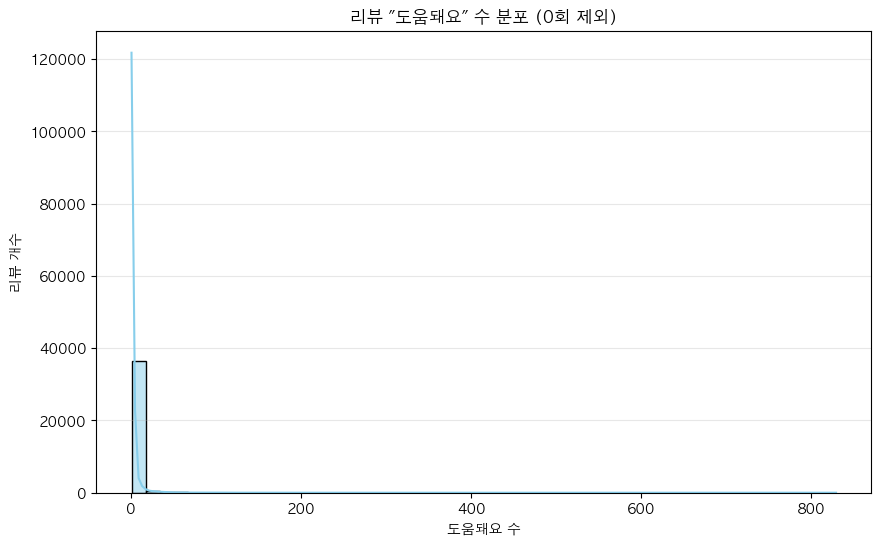

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='AppleGothic') 

# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 1. 전체 분포 (대부분 0이라서 0보다 큰 데이터만 필터링해서 보면 더 정확합니다)
helpful_data = df_rv[df_rv['도움돼요'] > 0]['도움돼요']

sns.histplot(helpful_data, bins=50, kde=True, color='skyblue')

plt.title('리뷰 "도움돼요" 수 분포 (0회 제외)')
plt.xlabel('도움돼요 수')
plt.ylabel('리뷰 개수')
plt.grid(axis='y', alpha=0.3)

plt.savefig('helpful_count_dist.png')

In [67]:
# 상위 20개의 빈도수 확인 (보통 0이 압도적 1위일 거예요)
helpful_counts = df_rv['도움돼요'].value_counts().head(20)
print("--- 도움돼요 빈도수 상위 20개 ---")
print(helpful_counts)

--- 도움돼요 빈도수 상위 20개 ---
도움돼요
0     510915
1      22446
2       6607
3       2639
4       1477
5        850
6        565
7        431
8        296
9        227
10       179
11       164
12       152
13       125
15        81
14        81
16        71
17        66
18        64
19        40
Name: count, dtype: int64


/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_77231/3158936282.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_rv['작성월'] = df_rv['작성일'].dt.to_period('M')


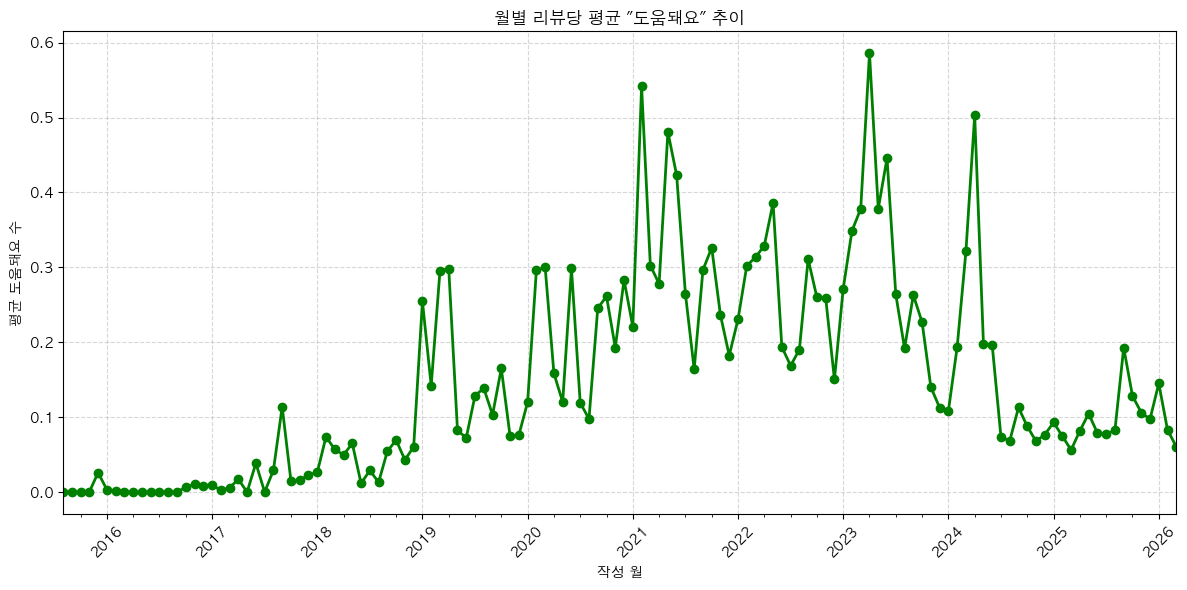

In [68]:
# '작성일'에서 월(Month) 추출
df_rv['작성월'] = df_rv['작성일'].dt.to_period('M')

# 월별 평균 도움돼요 수 계산
monthly_helpful = df_rv.groupby('작성월')['도움돼요'].mean()

# 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_helpful.plot(kind='line', marker='o', color='green', linewidth=2)

plt.title('월별 리뷰당 평균 "도움돼요" 추이')
plt.xlabel('작성 월')
plt.ylabel('평균 도움돼요 수')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('helpful_count_trend.png')

도움돼요 수 -> 불공평 방지 파생변수 생성
- n년 전에 쓴 리뷰는 '도움돼요'를 받을 시간이 n년이나 있었고,어제 쓴 리뷰는 하루뿐이었기에 
-> 이 둘을 그냥 비교하는 건 불공평하다

- 도움돼요/노출기간 식을 만들어서 장기 노출된 리뷰에 쏠리는 현상을 방지하고, 진짜 영향력 있는 리뷰를 가려낼 수 있다

7일 이상 필터 적용한 이유
- 작성된 지 7일 미만인 리뷰는 도움돼요를 받을 기회 자체가 충분하지 않다
- 예를 들어 어제 작성된 리뷰가 도움돼요를 1개 받았다면 일평균 지수가 1이 되어 수백 개를 받은 리뷰보다 높게 측정될 수 있다
- 최소 7일의 노출 기간이 보장된 리뷰만 분석 대상으로 삼아 이런 극단값을 제거했다

로그를 씌운 이유
- 단순히 도움돼요 / 노출일수로 나누면 노출 기간이 길수록 지수가 낮아지는 패널티가 너무 강하게 작용한다
- 로그를 적용하여 장기 노출 리뷰의 패널티 완화 -> 더 공정한 비교가 가능하다 

In [69]:
df_rv.columns

Index(['리뷰번호', 'goodsNo', '작성자', '리뷰내용', '평점', '체험단', '구매옵션', '키', '몸무게', '성별',
       '작성일', '만족도', '사진유무', '도움돼요', '만족도_응답여부', '사이즈', '화면 대비 색감', '퀄리티',
       '구김', '두께감', '신축성', '색감', '보온성', '퀄리티_점수', '보온성_점수', '신축성_점수', '두께감_점수',
       '구김_점수', '사이즈_편차', '사이즈_편차절대', '화면 대비 색감_편차', '화면 대비 색감_편차절대', '색감_편차',
       '색감_편차절대', '평점_raw', '작성월'],
      dtype='str')

In [70]:
import pandas as pd
import numpy as np

# 1. 날짜 데이터 형식 확정
df_rv['작성일'] = pd.to_datetime(df_rv['작성일'])

# 2. 분석 기준일 설정 (2026년 3월 31일)
기준일 = pd.to_datetime('2026-03-31').normalize().tz_localize(None)

# 3. [파생변수 1] 노출일수
df_rv['노출일수'] = (기준일 - df_rv['작성일'].dt.normalize().dt.tz_localize(None)).dt.days + 1

# 4. 7일 미만 리뷰 제거 (노출 기간이 너무 짧은 리뷰 제외)
before = len(df_rv)
df_rv = df_rv[df_rv['노출일수'] >= 7].copy()
after = len(df_rv)
print(f"7일 미만 제거: {before - after}개 제거 ({before}개 → {after}개)")

# 5. [파생변수 2] 일평균_도움돼요지수 (로그 스케일 적용)
# log1p = log(1 + 노출일수) → 장기 노출 리뷰 패널티 완화
df_rv['일평균_도움돼요지수'] = df_rv['도움돼요'] / np.log1p(df_rv['노출일수'])

# 6. [파생변수 3] 도움여부
df_rv['도움여부'] = (df_rv['도움돼요'] > 0).astype(int)

print(f"\n전처리 완료! 기준일({기준일.date()}) 대비 일평균 지수 생성 완료")

# 7. 결과 확인: 지수가 높은 순서대로 10개
display(df_rv[['작성일', '도움돼요', '노출일수', '일평균_도움돼요지수','도움여부']]
        .sort_values('일평균_도움돼요지수', ascending=False)
        .head(10))

7일 미만 제거: 440개 제거 (548248개 → 547808개)

전처리 완료! 기준일(2026-03-31) 대비 일평균 지수 생성 완료


,작성일,도움돼요,노출일수,일평균_도움돼요지수,도움여부
107009,2024-06-07 12:09:34+09:00,749,663,115.261231,1
451779,2021-02-22 11:17:19+09:00,829,1864,110.078104,1
256876,2023-06-01 16:20:56+09:00,712,1035,102.547522,1
104189,2024-04-15 20:01:48+09:00,615,716,93.535043,1
33391,2023-04-14 11:58:31+09:00,597,1083,85.427118,1
154590,2022-05-14 00:38:52+09:00,446,1418,61.451910,1
50624,2024-03-11 21:01:22+09:00,383,751,57.831081,1
308722,2020-10-29 23:14:47+09:00,356,1980,46.895436,1
8731,2020-06-03 18:19:38+09:00,353,2128,46.063059,1
104298,2024-04-19 18:19:57+09:00,302,712,45.970143,1
